In [ ]:
from google.colab import userdata
import os

In [ ]:
os.environ['GOOGLE_API_KEY'] = userdata.get('gemini_key')

In [ ]:
!pip install -U \
langchain \
langchain-community \
langchain-google-genai \
langgraph

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model = 'gemini-2.5-flash'
)

In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model = llm
)

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
from langchain.messages import HumanMessage,SystemMessage

In [ ]:
query_1 = HumanMessage(content="Hi, my name is ruDra.")

response = agent.invoke({
    "messages" : [query_1]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is ruDra.
================================== Ai Message ==================================

Hello ruDra! It's nice to meet you.

How can I help you today?


In [ ]:
query_2 = HumanMessage(content="Do you remember my name?")

response = agent.invoke({
    "messages" : [query_2]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Do you remember my name?
================================== Ai Message ==================================

No, I don't remember your name.

As an AI, I don't have personal memory of past conversations or users. Each interaction is fresh, and I don't store personal identifying information.


---

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

In [ ]:
agent = create_agent(
    model=llm,
    checkpointer=InMemorySaver(),
)

In [ ]:
query_1 = HumanMessage(content="Hi, my name is ruDra.")

response = agent.invoke(
    {"messages" : [query_1]},
    {"configurable" : {"thread_id" : "1"}}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is ruDra.
================================== Ai Message ==================================

Hello Rudra! It's nice to meet you. How can I help you today?


In [ ]:
query_2 = HumanMessage(content="What is my name")

response = agent.invoke(
    {"messages" : [query_2]},
    {"configurable" : {"thread_id" : "1"}}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, my name is ruDra.
================================== Ai Message ==================================

Hello Rudra! It's nice to meet you. How can I help you today?
================================ Human Message =================================

What is my name
================================== Ai Message ==================================

Your name is **Rudra**.


In [ ]:
system_message = SystemMessage(
    content="answer to user query concisely in 2-3 statements."
)

In [ ]:

human_message = HumanMessage(
    content = "Do you perform aptitude task"
)
response = agent.invoke(

    {'messages':[system_message,human_message]},
    {"configurable" : {"thread_id" : "1"}})
for msg in response['messages']:
  msg.pretty_print()

================================ System Message ================================

answer to user query concisely in 2-3 statements.
================================ Human Message =================================

Do you perform aptitude task
================================== Ai Message ==================================

As an AI, I don't possess aptitude or "perform" tasks in the human sense. However, I can process and help with tasks that assess abilities like logic, reasoning, and language comprehension.


In [ ]:
human_message = HumanMessage(
    content = "multiply 1112222, 33322223"
)
response = agent.invoke(

    {'messages':[system_message,human_message]},
    {"configurable" : {"thread_id" : "1"}})
for msg in response['messages']:
  msg.pretty_print()

================================ System Message ================================

answer to user query concisely in 2-3 statements.
================================ Human Message =================================

multiply 1112222, 33322223
================================== Ai Message ==================================

The product of 1,112,222 and 33,322,223 is 37,060,481,549,486.


In [ ]:
1112222*33322223 # llm predicted wrong

37061709509506

Adding Multiply tool to llm

In [ ]:
from langchain_core.tools import tool
@tool(name_or_callable='multiply',description='Multiply two numbers')
def multiply_tool(a: int, b: int) -> int:
  return a*b
type(multiply_tool)

langchain_core.tools.structured.StructuredTool

In [ ]:
result = multiply_tool.invoke({'a':1112222, 'b':33322223})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

37061709509506
multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [ ]:
agent_with_tool = create_agent(
    model=llm,
    tools=[multiply_tool]
)

In [ ]:
human_message = HumanMessage(
    content = "multiply 1112222, 33322223"
)
response = agent_with_tool.invoke(

    {'messages':[system_message,human_message]},
    {"configurable" : {"thread_id" : "1"}})
for msg in response['messages']:
  msg.pretty_print()

================================ System Message ================================

answer to user query concisely in 2-3 statements.
================================ Human Message =================================

multiply 1112222, 33322223
================================== Ai Message ==================================
Tool Calls:
  multiply (63aba405-f663-4248-baa5-e851455ab6b8)
 Call ID: 63aba405-f663-4248-baa5-e851455ab6b8
  Args:
    a: 1112222
    b: 33322223
================================= Tool Message =================================
Name: multiply

37061709509506
================================== Ai Message ==================================

The product of 1112222 and 33322223 is 37061709509506.


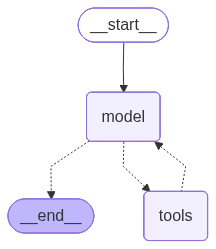

In [ ]:
from IPython.display import Image, display

display(Image(agent_with_tool.get_graph().draw_mermaid_png()))

We can also add built-in tools  
List of built-in tools:https://docs.langchain.com/oss/python/integrations/tools

DuckDuckGoSearch

In [ ]:
!pip install ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 26.6 MB/s eta 0:00:00


In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()

print(search_tool.name)
print(search_tool.description)
print(search_tool.args)


duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


In [ ]:
agent_with_tool = create_agent(
    model=llm,
    tools=[multiply_tool,search_tool]
)

In [ ]:
human_message = HumanMessage(
    content = "who won IPL match between MI and RCB"
)
response = agent_with_tool.invoke(

    {'messages':[system_message,human_message]},
    {"configurable" : {"thread_id" : "1"}})
for msg in response['messages']:
  msg.pretty_print()

================================ System Message ================================

answer to user query concisely in 2-3 statements.
================================ Human Message =================================

who won IPL match between MI and RCB
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (48f4ac9b-ef3f-41e5-86f7-5fd676378b78)
 Call ID: 48f4ac9b-ef3f-41e5-86f7-5fd676378b78
  Args:
    query: MI vs RCB IPL match winner
================================= Tool Message =================================
Name: duckduckgo_search

Royal Challengers Bengaluru, also known as RCB, formerly Royal Challengers Bangalore, are a professional Twenty20 cricket team based in Bengaluru, Karnataka, that competes in the Indian Premier League. RCB vs MI, 54th Match at Raipur, IPL, May 10 2026 - Match Result.RCB, after two defeats on the trot, have won a see-saw contest to get another 'W' to their name. MI and LSG are knocked out, and RC